#Анализ нарушений московского метрополитена.

Цель - выявить ключевые причины и закономерности нарушений в работе метрополитена

Задачи:
* Загрузить данные и познакомиться с ними;
* Предобработка данных и предварительное исследование;
* Исследовательский анализ;
* Формулировка выводов.


##1. Знакомство с датасетом, предобработка данных и предварительное исследование

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('/content/metro_m.xlsx')

In [3]:
df.head()

,Начало случая,Окончание случая,"Перерыв в движении, мин",id станции,Станционный путь,Перегон,Кол-во опоздавших поездов,Кол-во минут опоздания,Кол-во полных отмен,Кол-во участковых отмен,Кол-во внеплановых высадок пассажиров,Линия,Ответственная служба,Тип нарушения,Причины возникновения,Наименование устройства,Наименование детали устройства,Общая причина возникновения
0,1974-01-01 00:00:00,2022-01-01 00:01:00,0,83.0,NaN,NaN,0,0,0,0,0,Кольцевая,ЭС,Остановка эскалатора из-за нарушения правил по...,Остановка эскалатора из-за нарушения правил по...,Эскалатор,NaN,Действия пассажиров
1,1974-01-01 00:01:00,2022-01-01 00:03:00,0,87.0,NaN,NaN,0,0,0,0,0,Кольцевая,ЭС,Остановка эскалатора ручкой СТОП пассажирами,Остановка эскалатора ручкой СТОП пассажирами,Эскалатор,NaN,Действия пассажиров
2,1974-01-01 00:06:00,2022-01-01 00:08:00,0,49.0,NaN,NaN,0,0,0,0,0,Бутовская,ЭС,Остановка эскалатора ручкой СТОП из-за угрозы ...,Остановка эскалатора ручкой СТОП из-за угрозы ...,Эскалатор,NaN,Действия пассажиров
3,1974-01-01 00:11:00,2022-01-01 00:13:00,0,274.0,NaN,NaN,0,0,0,0,0,Таганско-краснопресненская,ЭС,Остановка эскалатора ручкой СТОП из-за угрозы ...,Остановка эскалатора ручкой СТОП из-за угрозы ...,Эскалатор,NaN,Действия пассажиров
4,1974-01-01 00:13:00,2022-01-01 00:15:00,0,81.0,NaN,NaN,0,0,0,0,0,Кольцевая,ЭС,Падение пассажира на эскалаторе без травм,Падение пассажира на эскалаторе без травм,Эскалатор,Огибной участок,Действия пассажиров


Преобразуем название столбцов.

In [4]:
df.columns = [col.lower().replace(' ', '_') for col in df.columns]

In [5]:
# df.head()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102151 entries, 0 to 102150
Data columns (total 18 columns):
 #   Column                                 Non-Null Count   Dtype         
---  ------                                 --------------   -----         
 0   начало_случая                          102151 non-null  datetime64[ns]
 1   окончание_случая                       102151 non-null  datetime64[ns]
 2   перерыв_в_движении,_мин                102151 non-null  int64         
 3   id_станции                             98111 non-null   float64       
 4   станционный_путь                       13517 non-null   object        
 5   перегон                                4040 non-null    object        
 6   кол-во_опоздавших_поездов              102151 non-null  int64         
 7   кол-во_минут_опоздания                 102151 non-null  int64         
 8   кол-во_полных_отмен                    102151 non-null  int64         
 9   кол-во_участковых_отмен                102151 no

Датасет содержит 102 151 строку, есть пропуски в:

* id_станции;
* станционный_путь;
* перегон;
* наименование_устройства;
* наименование_детали_устройства.


Типы данных указана корректно, изменения не нужны.

Стандартизируем данные, чтобы они были одного формата.

In [7]:
# Приведем к нижнему регистру и уберем пропуски
for colum in ['линия', 'ответственная_служба', 'тип_нарушения', 'причины_возникновения', 'наименование_устройства', 'наименование_детали_устройства', 'общая_причина_возникновения']:
  df[colum] = df[colum].str.lower().str.strip()

In [8]:
df_info = pd.DataFrame({
    'Data_type': df.dtypes,
    'Missing_values': df.isna().sum(),
    'missing_values_ratio(%)': df.isna().mean().round(2)*100,
    'unique_values': df.nunique()
})
df_info

,Data_type,Missing_values,missing_values_ratio(%),unique_values
начало_случая,datetime64[ns],0,0.0,92304
окончание_случая,datetime64[ns],0,0.0,94616
"перерыв_в_движении,_мин",int64,0,0.0,48
id_станции,float64,4040,4.0,266
станционный_путь,object,88634,87.0,7
перегон,object,98111,96.0,480
кол-во_опоздавших_поездов,int64,0,0.0,3
кол-во_минут_опоздания,int64,0,0.0,49
кол-во_полных_отмен,int64,0,0.0,9
кол-во_участковых_отмен,int64,0,0.0,44


In [9]:
# df.head()

Проверим наличие дублей:

In [10]:
dubl = df.duplicated(keep = 'first').sum()
if dubl > 0:
  print(f'в датасете есть дубли. Кол-во дублей: {dubl}')
else:
  print('Дублей нет')

в датасете есть дубли. Кол-во дублей: 609


Точно не могу сказать, дубли это или нет, так как не знаю специфики метро. Давайте считать, что это дубли, т. к. данные сходятся по всем столбцам.

Удалим явные дубли:

In [11]:
df.drop_duplicates(keep = 'first', inplace = True)
df.shape[0]

101542

Проверим столбцы:

* линия
* ответственная_служба
* общая_причина_возникновения

на наличие неявных дублей.

In [12]:
for cols in ['линия', 'ответственная_служба', 'общая_причина_возникновения']:
  print()
  print(df[cols].value_counts())
  print('==' * 50)


линия
большая кольцевая             14735
кольцевая                     14105
замоскворецкая                 9177
люблинско-дмитровская          9117
серпуховско-тимирязевская      8317
калужско-рижская               7900
таганско-краснопресненская     7665
сокольническая                 7477
арбатско-покровская            7370
некрасовская                   5060
солнцевская                    4425
калининская                    3162
бутовская                      1886
филёвская                      1146
Name: count, dtype: int64

ответственная_служба
эс      72922
т        7823
б        7203
дитс     4663
э        4451
ш        1946
спо      1505
эм        553
п         476
Name: count, dtype: int64

общая_причина_возникновения
действия пассажиров                                                               73757
отказ/неисправность технических средств                                           15111
неисправность не подтвердилась/устройства отработали штатно                        7

Неявных дублей не обнаружил.

In [13]:
# df[df.duplicated()]

**Промежуточные итоги:**

* Загрузили датасет в датафрейм df;
* Изменили название столбцов;
* Проанализировали структуру:
  * типы данных указаны корректно;
  * есть пропуски в некоторых столбцах. С пропусками ничего делать не будем, т. к. их в текущей ситуации нельзя заполнить корректно и удалить нельзя, т. к. процент пропусков составляет от 4% до 96%.
* Строковые данные привели к единому формату;
* Нашел 609 явных дублей, удалил их.
* Конечный датафрейм имеет 101 542 строки.

##2. Исследовательский анализ

In [14]:
# df.head()

Смущает начало случая, есть года 1974, проверим минимальные и максимальные даты.

In [15]:
stats_df = df[['начало_случая', 'окончание_случая']].agg(['min', 'max'])
print(stats_df)

          начало_случая    окончание_случая
min 1974-01-01 00:00:00 1974-01-01 08:31:00
max 1975-12-25 23:53:00 2023-12-26 02:39:00


В данных смущают большие интервалы между началом события и окончанием. в некоторых ситуациях, интервал доходит почти до 60 лет.

Для дальнейшего анализа возьмем данные с окончанием события в 2023 году.

In [16]:
df_2023 = df[df['окончание_случая'].dt.year == 2023].copy()

print(f'Было строк: {len(df)}')
print(f'Стало строк: {len(df_2023)}')

Было строк: 101542
Стало строк: 56235


За 2023 год было устранено 56 235 происшествий.
Посмотрим, на какую службу больше всего приходилось происшествий.

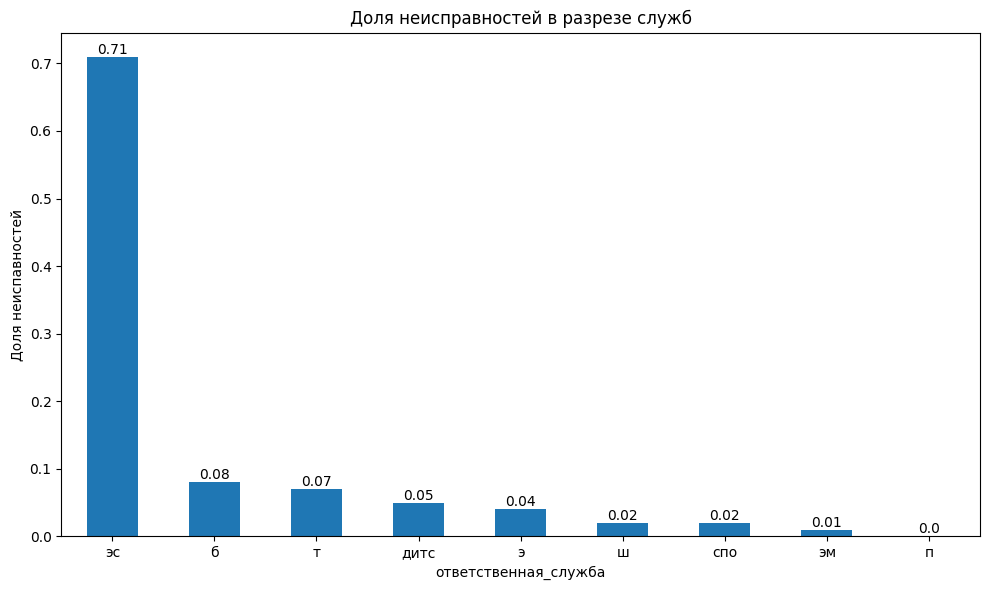

In [17]:
df_service = df_2023['ответственная_служба'].value_counts(normalize = True).round(2)


plt.figure(figsize = (10, 6))
df_service.plot(kind = 'bar',
                rot = 360)

plt.ylabel('Доля неиспавностей')
plt.title('Доля неисправностей в разрезе служб')

for i, v in enumerate(df_service):
  plt.text (i, v, str(v), ha = 'center', va = 'bottom')

plt.tight_layout()


plt.show()

Удобно выделяет ЭС - эскалаторная служба. На нее приходится более 70% всех неисправностей




Теперь посмотрим на ТОП-7 типов нарушений.

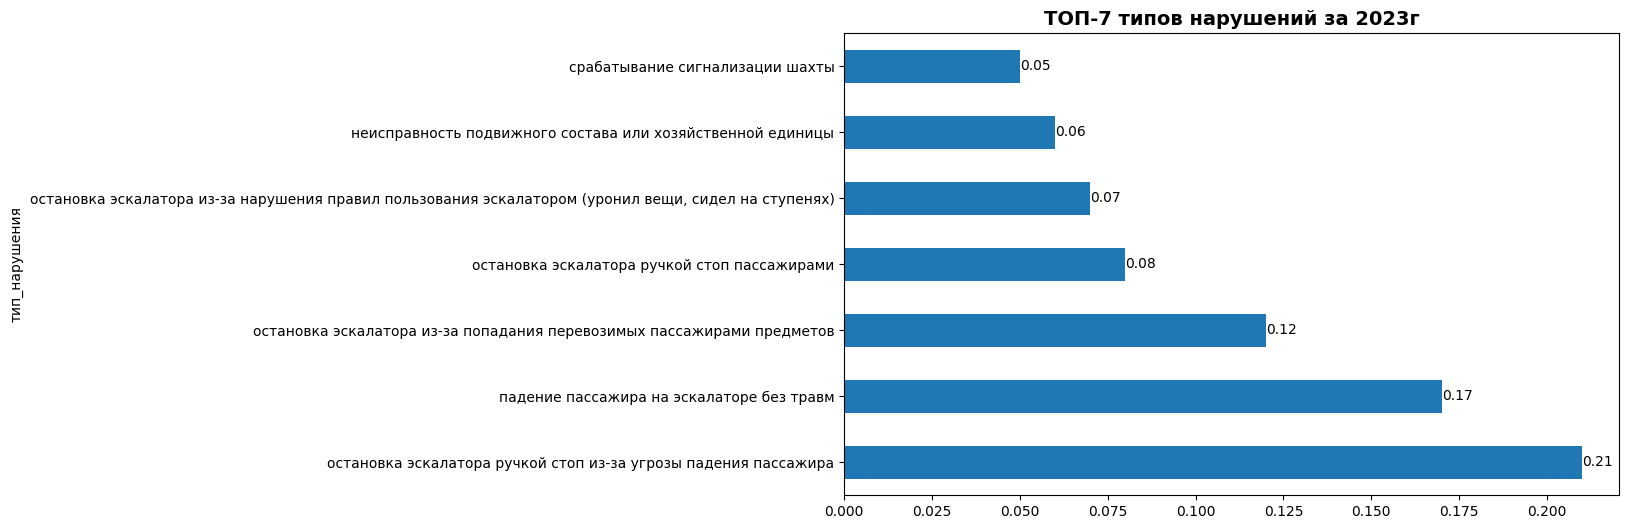

In [18]:
df_violation = df_2023['тип_нарушения'].value_counts(normalize=True).round(2).iloc[:7]

plt.figure(figsize = (10, 6))

df_violation.plot(kind = 'barh')

plt.title('ТОП-7 типов нарушений за 2023г', fontsize = 14, fontweight = 'bold')
for i, v in enumerate(df_violation):
  plt.text(v, i, str(v), va ='center')

plt.show()

Тут также часто встречаются эскалаторы. Они входят в топ-5 самых частых типов нарушений.

Посмотрим на распределение по общим причинам.

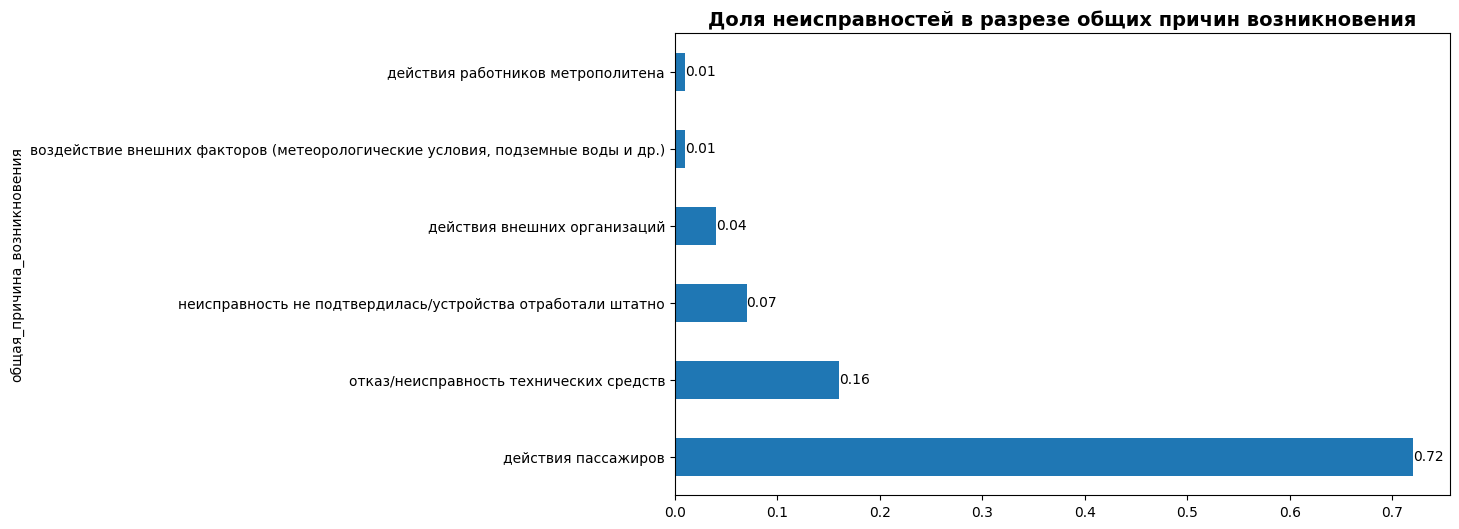

In [19]:
common_cause = df_2023['общая_причина_возникновения'].value_counts(normalize=True).round(2)

plt.figure(figsize=(10, 6))
common_cause.plot(kind = 'barh')

plt.title('Доля неисправностей в разрезе общих причин возникновения', fontsize = 14, fontweight = 'bold')

for i, v in enumerate(common_cause):
  plt.text(v, i, str(v), va = 'center')

#plt.tight_layout()

plt.show()

Более чем в 70% случаев причинами нарушений становятся сами пассажиры.

Я бы еще обратил внимание на «отказ/неисправность технических средств» и «неисправность не подтвердилась».

**Промежуточные выводы:** чаще всего неисправности встречаются в эскалаторах, и чаще всего причинами являются пассажиры. Но также стоит обратить внимание на причины нарушений:

* отказ/неисправность технических средств - 15%
* неисправность не подтвердилась - 7%

In [20]:
# df_2023.head()

In [21]:
df_2023['наименование_устройства'].value_counts().iloc[:3]

,count
наименование_устройства,
эскалатор,39904
состав,4944
вш,2868


Отдельно посмотрим, какая деталь устройства чаще всего является причиной нарушения на эскалаторе.

In [22]:
df_escalator = df_2023[df_2023['наименование_устройства'] == 'эскалатор']

df_escalator['наименование_детали_устройства'].value_counts().iloc[:6]

,count
наименование_детали_устройства,
вогнутый участок,4974
нижняя входная площадка,2955
середина наклона,2026
верхняя входная площадка,277
огибной участок,204
плафон,98


Детали, которые чаще всего приводят к нарушению работы в эскалаторе:

* Вогнутый участок
* Нижняя входная площадка
* Середина наклона

Еще посмотрим аналогичную статистику по составам, так у них тоже много нарушений и работы, и это один из ключевых составляющих метро.

In [23]:
df_train = df_2023[df_2023['наименование_устройства'] == 'состав']
df_train['наименование_детали_устройства'].value_counts().iloc[:10].reset_index()

,наименование_детали_устройства,count
0,дверной привод,204
1,при проверке состава неисправность не подтверж...,173
2,блок управления дверьми буд,149
3,преобразователь собственных нужд псн,143
4,неисправность контактов в разъемах и соединениях,136
5,выключатель путевой концевой впк,115
6,блок управления тяговым приводом бутп,102
7,датчик перегрева букс дпб,71
8,дверной воздухораспределитель двр,68
9,посторонний предмет,64


Тут нет таких ярко выраженных деталей, как у эскалатора. Но интересный момент здесь, что на втором месте стоит «при проверке состава неисправность не подтверждена». Т.е. здесь можно подумать, как автоматизировать первичную проверку, чтобы не тратить много времени на такие «ложные» нарушения.

Проанализируем, как инциденты распределены по веткам метро.

In [24]:
df_lines = df_2023.groupby('линия')['начало_случая'].count().sort_values(ascending = False)
df_lines = df_lines.rename('Кол-во нарушений работы')
display(df_lines)

,Кол-во нарушений работы
линия,
большая кольцевая,11085
кольцевая,6987
люблинско-дмитровская,4863
замоскворецкая,4652
серпуховско-тимирязевская,4326
таганско-краснопресненская,4016
калужско-рижская,3972
сокольническая,3818
арбатско-покровская,3766


Больше всего инцидентов происходит на кольцевых линиях.
Предполагаю, что это связано с тем, что это наиболее нагруженные линии. Проверить это на данных не могут, т. к. нет информации по пассажиропотоку.

На этих линиях требуется больше персонала, который будет устранять инциденты.

###Временной анализ

Выделим месяца и посмотрим нарушения работы в их разрезе.

*Важное примечание: так как столбец «начало_случая» у нас в рамках 1974–1975 годов, то для анализа будем использовать «окончание_случая». Будем считать, что инциденты устраняли в тот день, в который они возникли.*

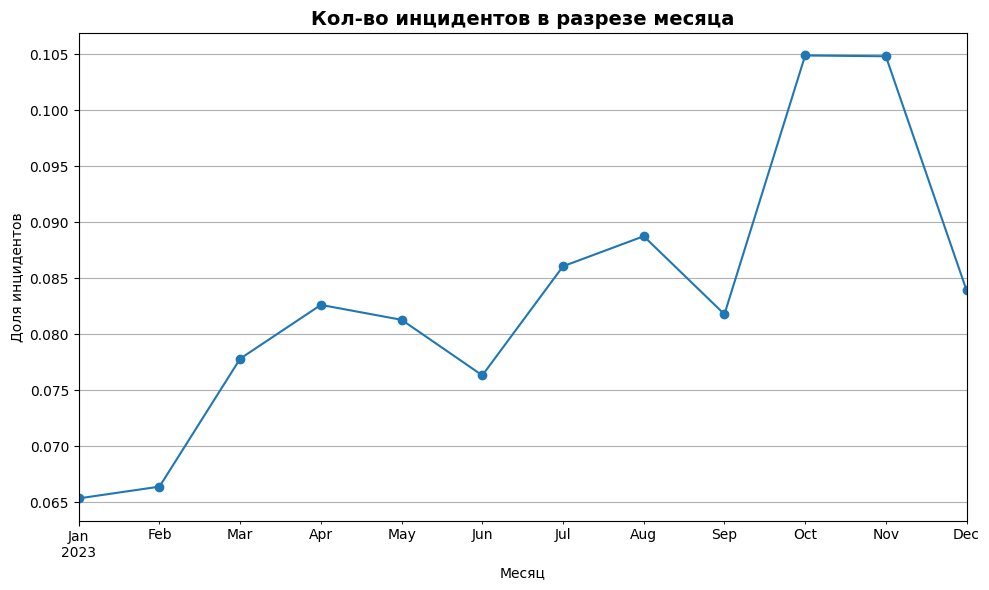

In [25]:
df_2023['month'] = df_2023['окончание_случая'].dt.to_period('M')

df_month = df_2023['month'].value_counts(normalize=True).reset_index().sort_values(by = 'month')
df_month.columns = ['month', 'incident_cnt']


df_month.plot.line(x = 'month',
                   y = 'incident_cnt',
                   marker = 'o',
                   figsize = (10, 6),
                   legend=False,
                   )

plt.title('Кол-во инцидентов в разрезе месяца', fontsize = 14, fontweight = 'bold')
plt.xlabel('Месяц')
plt.ylabel('Доля инцидентов')
plt.grid(True)
plt.tight_layout()


plt.show()

С начала года график имеет восходящую тенденцию.
Пики наблюдаются в октябре и ноябре. Такая ситуация может быть связана с погодными условиями (вода, перепады температур) все это может влиять на инфраструктуру.

В декабре проседания, т. к. данные только до 26.12, и многие уходят в отпуска перед новогодними праздниками. Также есть проседания в июне и сентябре, это тоже может быть связано с отпускными сезонами.

Посмотрим на сезонность в зависимости от дня недели.

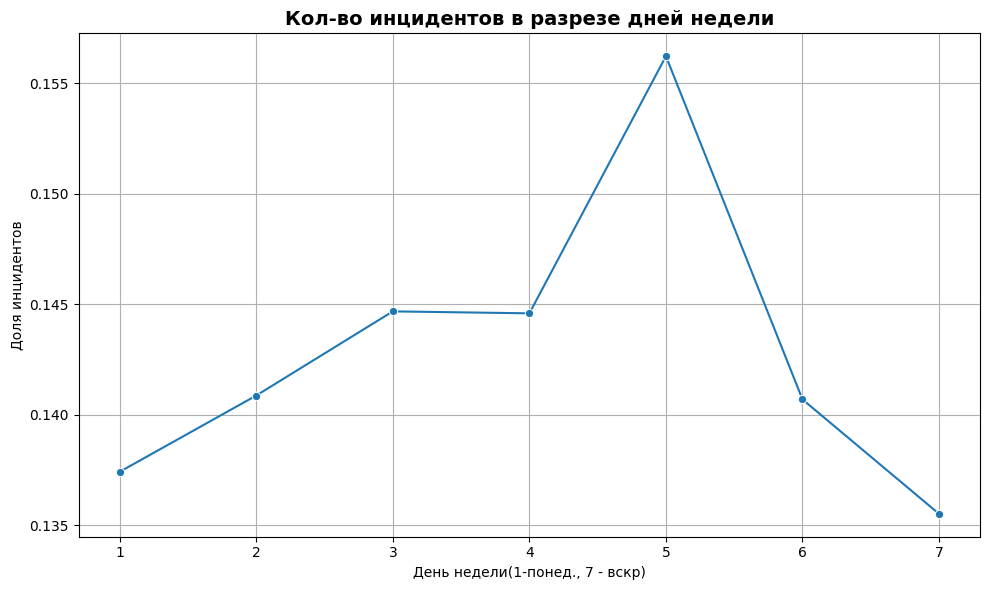

In [26]:
df_2023['week_day'] = df_2023['окончание_случая'].dt.dayofweek + 1
# df_2023.head()

df_week_day = df_2023['week_day'].value_counts(normalize=True).reset_index().sort_values(by = 'week_day')
df_week_day.columns = ['week_day', 'incident_cnt']

plt.figure(figsize = (10, 6))

sns.lineplot(data = df_week_day,
             x = 'week_day',
             y = 'incident_cnt',
             marker = 'o')

plt.title('Кол-во инцидентов в разрезе дней недели', fontsize = 14, fontweight = 'bold')
plt.xlabel('День недели(1-понед., 7 - вскр)')
plt.ylabel('Доля инцидентов')

plt.grid()
plt.tight_layout()

plt.show()


Посмотрим на кол-во неисправностей в абсолютных единицах.

In [27]:
df_2023['week_day'].value_counts()

,count
week_day,
5,8785
3,8136
4,8131
2,7922
6,7912
1,7728
7,7621


Пятница - лидер по кол-ву нарушений работы, но разница с воскресеньем (самый «спокойный» день недели) ~2%, т. е. не так много. Пятница здесь может лидировать по причине того, что это крайний день рабочей недели, люди:

* выезжают за город на выходные;
* студенты из общежитий и люди, которые работают вахтами, могут уезжать домой;
* также в конце рабочей недели люди могут отмечать окончание работы и быть нетрезвыми в метро.

по пятницам стоит увеличить кол-во персонала

Далее проанализируем кол-во нарушений работы в разрезе часов, выдели несколько интервалов.

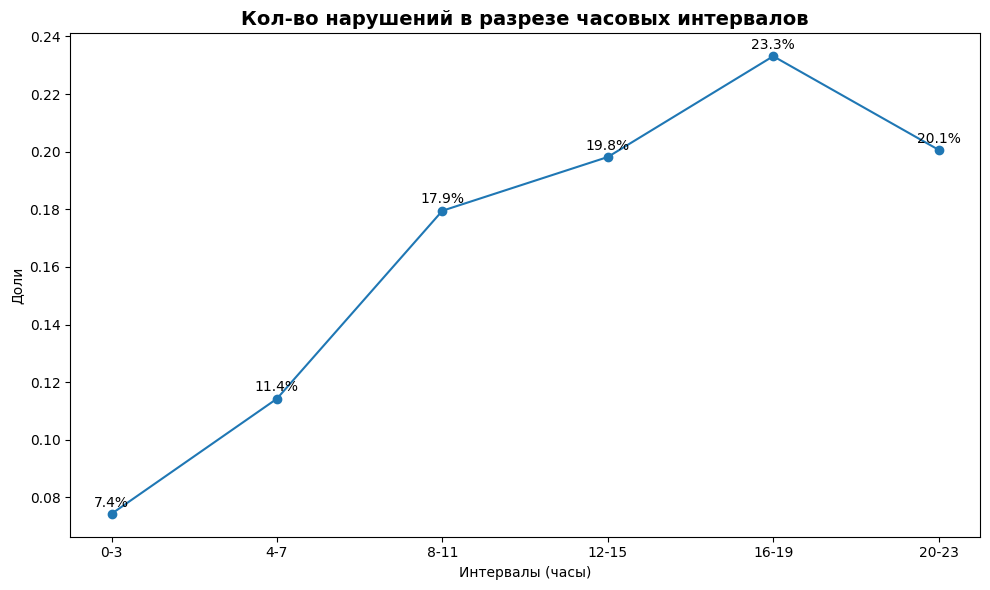

In [28]:
df_hours = df_2023.copy()
df_hours['hours'] = df_hours['начало_случая'].dt.hour


bins = [-1, 3, 7, 11, 15, 19, 23]
labels = ['0-3', '4-7', '8-11', '12-15', '16-19', '20-23']
df_hours['group_hours'] = pd.cut(df_hours['hours'],
                                 bins = bins,
                                 labels = labels)

df_hours_plot = df_hours['group_hours'].value_counts(normalize=True).reset_index()
df_hours_plot.columns = ['group_hours', 'cnt']
df_hours_plot = df_hours_plot.sort_values(by = 'group_hours')



df_hours_plot.plot(kind = 'line',
                   x = 'group_hours',
                   y = 'cnt',
                   figsize = (10, 6),
                   marker = 'o',
                   legend = False)
plt.title('Кол-во нарушений в разрезе часовых интервалов', fontsize = 14, fontweight = 'bold')
plt.xlabel('Интервалы (часы)')
plt.ylabel('Доли')

for i, v in enumerate(df_hours_plot['cnt']):
  plt.text(i, v + 0.0015, f'{v:.1%}', ha = 'center', va = 'bottom')

# plt.grid()
plt.tight_layout()

plt.show()


Меньше всего нарушений в интервалах 0–3, но это и логично, так как метро работает с 5:30 до 01:00, далее процент инцидентов растет до вечернего времени и пика достигает в интервале 16–19, это время, когда большинство людей возвращается с работы/учебы. После 19 часов кол-во нарушений начинает снижаться.

Рекомендация аналогична предыдущим — увеличение кол-ва персонала метрополитена в наиболее интенсивные интервалы (8–23).

**Промежуточные итоги:**

* Чаще всего нарушения работы происходит на эскалаторах. 39 904 неисправности за 2023 год. А те детали, которые. Больше всего встречается неисправностей в деталях: вогнутый участок, нижняя входная площадка, середина наклона.
* У составов 4 944 поломки. И чаще всего страдает дверной привод. * Стоит обратить на 173 поломки, которые не подтвердились.
* Больше всего неисправностей встречает на кольцевых линиях.
* Самые «ломучие» месяцы: октябрь и ноябрь. В январе меньше всего поломок.
* Если смотреть в разрезе дней, то больше всего инцидентов происходит по пятницам, а меньше в воскресенье.
* Если в разрезе часовых интервалов, то интервал 16-19 имеет наибольшую долю нарушений работы (23,3%). Меньше всего в интервалах 0-7 часов (7,4% с 0- и 11,4% с 4-7).

###Кросс-анализ

Посомтрим какие типы нарушений характерны для каждой линии

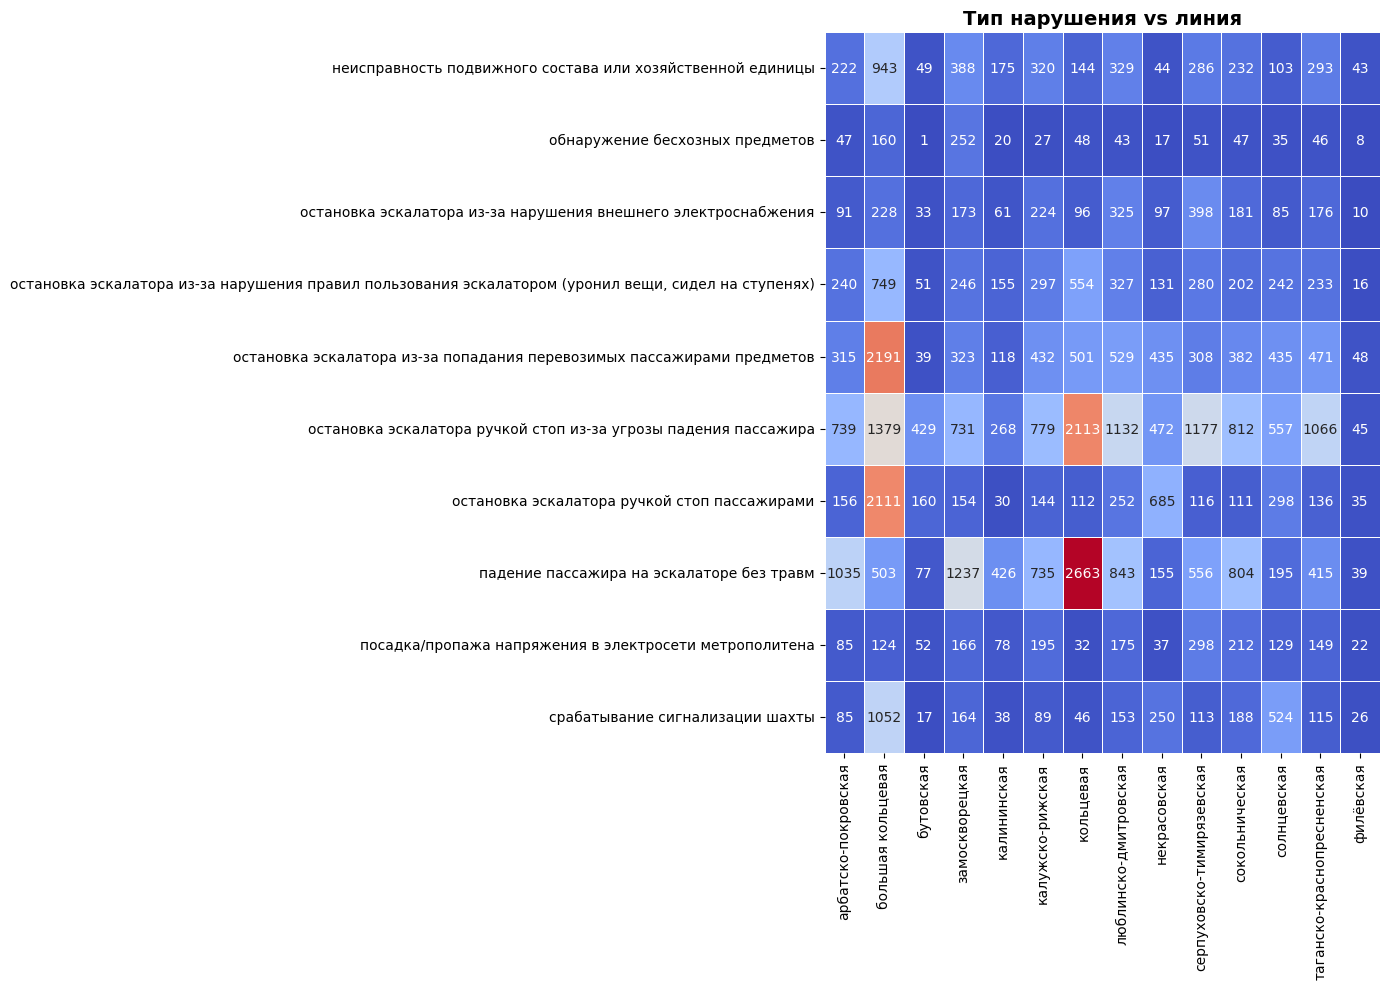

In [29]:
top_types = df_2023['тип_нарушения'].value_counts().head(10).index # топ 10 нарушений
# top_types


df_top = df_2023[df_2023['тип_нарушения'].isin(top_types)]
# df_top

crosstab_data = pd.crosstab(df_top['тип_нарушения'], df_top['линия'])
# crosstab_data
plt.figure(figsize=(14, 10))

sns.heatmap(crosstab_data,
            annot = True,
            fmt = 'd',
            cmap = 'coolwarm',
            linewidths = 0.5,
            cbar = False)

plt.title('Тип нарушения vs линия', fontsize = 14, fontweight = 'bold')
plt.xlabel('')
plt.ylabel('')

plt.tight_layout()

plt.show()


Больше всего инцидентов встречается на кольцевых линиях, и все они связаны с эскалаторами и пассажирами.
Тут стоит подумать над тем, чтобы в метро транслировать правила поведения на эскалаторах, это может снизить количество происшествий.

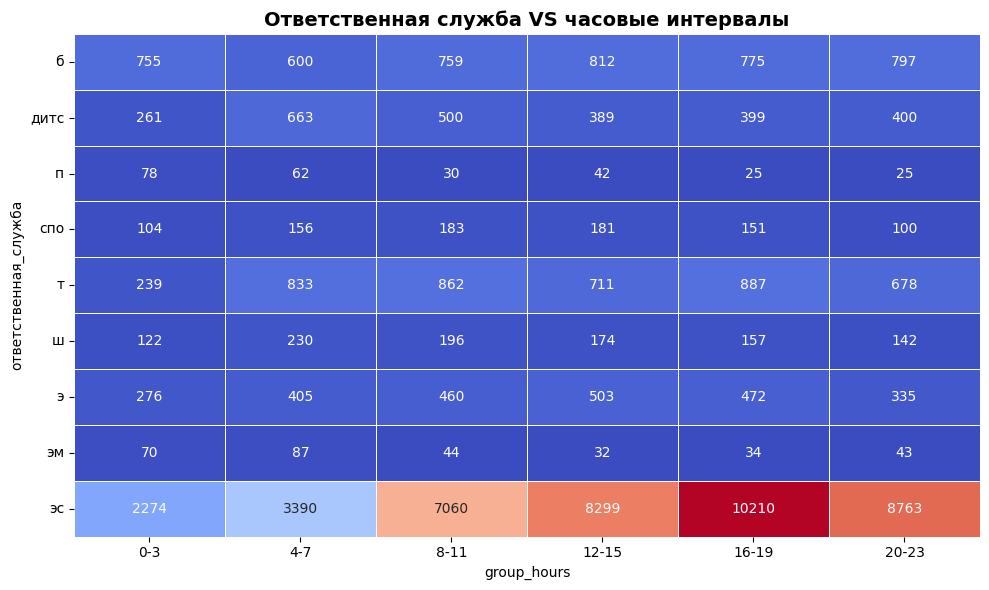

In [30]:
df_hours_pivot = df_hours.pivot_table(index = 'ответственная_служба',
                     columns = 'group_hours',
                     aggfunc = 'size',
                     fill_value = 0,
                     observed=False)

plt.figure(figsize = (10, 6))

sns.heatmap(df_hours_pivot,
            annot = True,
            fmt = 'd',
            cmap = 'coolwarm',
            cbar = False,
            linewidths = 0.5,
           )

plt.title('Ответственная служба VS часовые интервалы', fontsize = 14, fontweight = 'bold')
plt.yticks(rotation = 360)
plt.tight_layout()

plt.show()

* Эскалаторная служба загружена в интервал 8–23 часа, пик приходится на 16–19 часов.
* ТП (служба подвижного состава) загружена работой с 4 до 23 часов. В часы пик самая большая нагрузка.
* ДИТС (дирекция информационных технологий и систем связи) наиболее активна в утренние часы и до полудня, далее активность спадает.
* Э (служба электроснабжения) активна в течение дня, кроме вечернего (20–23) и ночного времени (0–3).
* ЭМ (электромеханическая служба) наиболее активна в ночное и ранее утреннее время. Так же как и П (служба пути).
* По остальным службам можно сказать, что нет сильных скачков.

In [31]:
# df_2023.head()

Проанализируем связь перерыв_в_движении и кол-во_опоздавших_поездов.

In [32]:
service = ['т', 'п'] # оставим службы, которые влияют на подвижной состав и пути

df_service = df_2023[df_2023['ответственная_служба'].isin(service)]
# display(df_service.head())


print('========основная статистика========')
print()
display(df_service[['перерыв_в_движении,_мин', 'кол-во_опоздавших_поездов']].describe())

========основная статистика========



,"перерыв_в_движении,_мин",кол-во_опоздавших_поездов
count,4472.000000,4472.000000
mean,0.182021,0.010957
std,5.521432,0.110369
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,330.000000,2.000000


- 75% инцидентов не привели к остановке движения (перерыв = 0 мин)
- 75% инцидентов не вызвали опозданий поездов (опоздавших = 0)
- Средний перерыв составляет всего 0.18 минут, но это значение искажено редкими выбросами
- Типичный (медианный) перерыв = 0 минут

In [33]:
# df_service['кол-во_минут_опоздания'].unique()

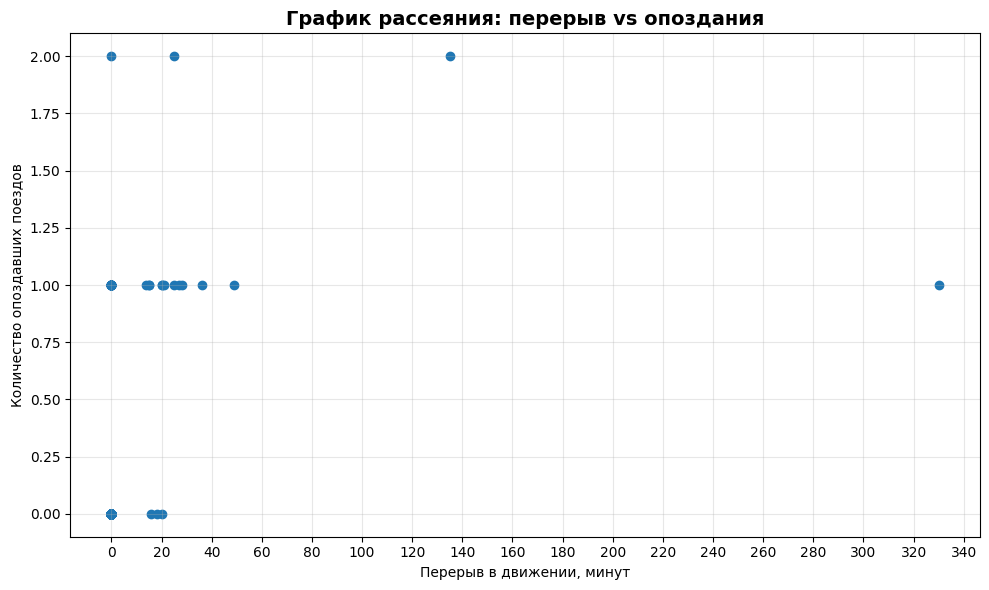

In [34]:
import numpy as np

plt.figure(figsize=(10, 6))
plt.scatter(df_service['перерыв_в_движении,_мин'], df_service['кол-во_опоздавших_поездов'])

plt.title('График рассеяния: перерыв vs опоздания', fontsize = 14, fontweight = 'bold')
plt.xlabel('Перерыв в движении, минут')
plt.ylabel('Количество опоздавших поездов')
plt.grid(True, alpha=0.3)


max_break = df_service['перерыв_в_движении,_мин'].max()
ticks = np.arange(0, max_break + 20, 20)
plt.xticks(ticks)

plt.tight_layout()

plt.show()

График показывает наличие связи между перерывом и опозданиями, но она не является строгой линейной зависимостью.

Наибольшее кол-во опзданий начинается при перерыве в 17 мин, хотя и встречаются интресные случаи когда при перерыве в 0 мин, есть 2 опоздания и при перерывах 15 -20 мин по 0 опозданий

##3. Выводы

Цель - выявить ключевые причины и закономерности нарушений в работе метрополитена.


Предобработка данных:
* названия столбцов переведены в нижний регистр, строковые значения приведены к единому формату;
* удалено 609 полных дублей, итого 101 542 записи.
* оставлены только записи с окончанием инцидента в 2023 году. 56 235 событий;
* в некоторых столбцах есть пропуски, но они не удалялись, т.к. не критичны для анализа.
* из даты окончания выделены месяц, день недели и час для временных срезов

Общий анализ:

* Большие интервалы между началом случая и окончанием, ~60 лет.
* 71% нарушений приходится на эскалаторную службу (ЭС).
* 72% нарушений вызваны действиями пассажиров.
* У эскалаторов чаще всего страдают: вогнутый участок, нижняя входная площадка, середина наклона.
* ТОП-3 устройства по нарушениям: эскалатор (39 904), состав (4 944), ВШ (2 868).
* У составов чаще страдает дверной привод (204), а на втором месте неподтвержденные неисправности (173) признак проблем с диагностикой.
* Больше всего нарушений работы наблюдается на кольцевых линиях: Большая кольцевая - 11 085 и Кольцевая - 6 987.

Временной анализ:
* Месяцы: пик в октябре–ноябре (погодный фактор).
* Дни недели: максимум в пятницу, минимум в воскресенье.
* Часы: наибольшая нагрузка 16–19 (23.3% инцидентов), ночью (0–3) -  минимум.

Кросс-анализ:

* Наибольшее число нарушений  на кольцевых линиях. и все они связанны с эскалаторами
* Эскалаторная служба активна с 8 до 23 часов, пик — 16–19.
* 75% инцидентов не приводят к остановке движения и опозданиям поездов.

Общие выводы:
* Главная причина нарушений - поведение пассажиров.
* Самый проблемный объект - эскалатор, его уязвимые узлы требуют усиленного контроля.
* Временные пики нарушений:  вечер пятницы осенью - самое аварийное время.
* Большинство сбоев не парализуют движение, но требуют ресурсов на устранение.
* Ложные вызовы по составам указывают на слабую диагностику.

Рекомендации:

* Усилить профилактику проблемных узлов эскалаторов (вогнутый участок, входные площадки).
* Проводить информационные кампании о правилах поведения на эскалаторе.
* Увеличить число дежурных в часы пик (16–19) и по пятницам.
* Улучшить систему диагностики, чтобы сократить число ложных вызовов.
* Усилить смены на кольцевых линиях.
* Проводить сезонную подготовку к осеннему периоду.
* Стремиться устранять нарушения за 15 мин и менее

Особый упор надо делать на работу с пассажирами и профилактику эскалаторов. Это позволит сократить до 70% нарушений без значительных финансовых затрат.